# Explore the space around a fiber segment to look where the fiber can 'see'

In [1]:
import pykonal 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr 
from tqdm import tqdm

import numpy as np 
import pandas as pd 
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


import sys
import os

sys.path.append(os.path.abspath("../src"))
from fct_DAS_sensitivity import *

# 1. create travel time grid 

In [2]:
solver = pykonal.solver.PointSourceSolver(coord_sys="cartesian")
solver.velocity.min_coords = 0, 0, 0
solver.velocity.node_intervals = 5, 5, 5
solver.velocity.npts = 100, 100, 100

In [32]:
### INPUT ###
# Source
x_source = 500. # must be float 
y_source = 500. # must be float
z_source = 100. # must be float 
# Grid 
x_spacing = 50
y_spacing = 50
z_spacing = 50
x_min = 0
y_min = 0
z_min = 0
x_max = 1000
y_max = 1000
z_max = 1000

# create your grid in dimension x_y_z 
# !!! dimention must mach grid dimention above 
velocity_gid = np.full((int((y_max - y_min)/y_spacing),int((x_max - x_min)/x_spacing),int((z_max - z_min)/z_spacing)), 0.5)

velocity_gid[:,:,-int(velocity_gid.shape[2]/2):] = 1.5

for id in range(velocity_gid.shape[2]):
    velocity_gid[:,:,id] = velocity_gid[:,:,id] 
### Initiate Dataset to contain data ###
velocities = xr.DataArray(velocity_gid, dims = ['latitude', 'longitude', 'depth'], 
                            coords={'latitude' : np.linspace(y_min,y_max, int((y_max - y_min)/y_spacing)), 
                                    'longitude' : np.linspace(x_min,x_max, int((x_max - x_min)/x_spacing)), 
                                    'depth' : np.linspace(z_min,z_max, int((z_max - z_min)/z_spacing)),})

### Create and run model ###
solver = pykonal.solver.PointSourceSolver(coord_sys="cartesian")
solver.velocity.min_coords = 0, 0, 0
solver.velocity.node_intervals = z_spacing, y_spacing, x_spacing
solver.velocity.npts = int((z_max - z_min)/z_spacing), int((y_max - y_min)/y_spacing), int((x_max - x_min)/x_spacing)
solver.velocity.values =velocities.transpose( 'depth','latitude', 'longitude').values

# Initialize the source location with a random location within the
# computational grid.
solver.src_loc = np.array([z_source,y_source,x_source]).astype(float)

# Compute traveltimes.
solver.solve()

tt = solver.tt.values
# only if issues with Nan tt[np.isinf(tt)] = 0
travel_times = velocities.copy().transpose( 'depth','latitude', 'longitude')
travel_times.values  = tt
travel_times = travel_times.transpose('latitude', 'longitude', 'depth')

# 2. DAS fiber parameters 

In [39]:
das = DASSensor(
    azimuth=0,
    dip=90,
    gauge_length=10,
    wavelength=100,
    velocity=1000, 
    latitude = None,
    longitude = None,
    depth = None,
)

In [40]:
wave_type = 'P'

# 3. get sensitivity to all node in space

In [41]:
num_elements = travel_times.values.size
kernel = travel_times.copy()
for idx in tqdm(range(num_elements)):
        i, j, k = np.unravel_index(idx, travel_times.values.shape)
        y_coord = travel_times.coords['latitude'][i]
        x_coord = travel_times.coords['longitude'][j]
        z_coord = travel_times.coords['depth'][k]
        end = np.array([z_coord,y_coord,x_coord]).astype(float)
        try:
            rays = solver.trace_ray(end)
            z, y, x = rays.T  
            first_node = x[2]-x[0],y[2]-y[0],z[2]-z[0]
            ray_az = np.degrees(np.arctan2(first_node[1],first_node[0]))
            ray_dip = np.degrees(np.arctan2(first_node[2], np.sqrt(first_node[0]**2+first_node[1]**2)))
            kernel.values[i,j,k] = das.sensitivity(wave_type, ray_az, ray_dip) 
        except Exception as e:
            kernel.values[i,j,k] = np.nan 

100%|██████████| 8000/8000 [00:22<00:00, 361.23it/s]


C:\Users\liliv\AppData\Local\Temp\ipykernel_29300\3396094425.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('seismic')  # You can also try 'coolwarm', 'bwr', 'RdBu'


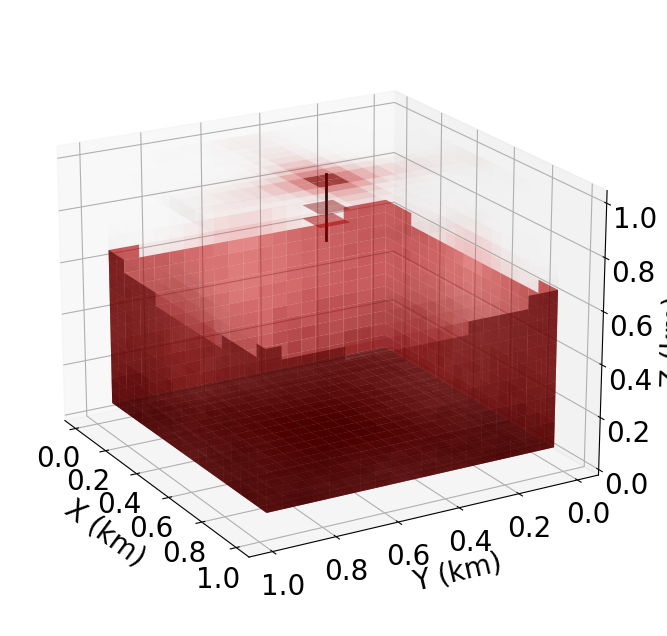

In [42]:
# Fiber orientation (user-defined)
azimuth_deg = das.metadata()['azimuth']    # Now 0° points in X direction
dip_deg = das.metadata()['dip']+90    # Dip from horizontal, downward positive

# Convert to radians
azimuth = np.radians(azimuth_deg)
dip = np.radians(dip_deg)

# Direction vector with new convention
dx = np.sin(dip) * np.sin(azimuth)  # X points at azimuth=0
dy = np.sin(dip) * np.cos(azimuth)  # Y at 90°
dz = np.cos(dip)  
                  # Z is vertical (dip)
# --- Center of the volume ---
shape = kernel.values.shape  # shape = (nx, ny, nz)
center = np.array(shape) / 2  # voxel center coordinates

# --- Define the fiber line (small segment centered in the volume) ---
length = 5  # adjust this for how long the fiber appears
t = np.linspace(-length / 2, length / 2, 50)
x_line = center[0] + t * dx
y_line = center[1] + t * dy
z_line = (center[2] + t * dz)+(((z_max/2)-z_source)/z_spacing)

# Use signed data (important for diverging colormap)
data = kernel.values
data[np.isinf(data)] = 0
data = data[:, :, ::-1]
data[np.isnan(data)] = 0

# Define symmetric normalization range around 0
vmax = np.max(np.abs(data))
vmin = -vmax
norm_data = (data - vmin) / (vmax - vmin)  # Normalize to [0, 1] for color mapping

# Transparency based on magnitude
alpha = (np.abs(data) / vmax) ** 1.5  # Makes low values more transparent

# Diverging colormap
cmap = cm.get_cmap('seismic')  # You can also try 'coolwarm', 'bwr', 'RdBu'
colors = cmap(norm_data)
colors[..., -1] = alpha  # Set alpha channel

# Voxels to display (cutoff to remove noise)
threshold = 0
filled = np.abs(data) > threshold * vmax

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot( projection='3d')
# --- Plot the fiber ---

ax.voxels(filled, facecolors=colors, edgecolors=None)

# Axes & view
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
#ax.set_zticks([0, 5, 10, 15, 20])
ax.tick_params(axis='z', labelsize=20)

# Increase label font size
ax.set_xlabel("X (km)", fontsize=20, labelpad=10)
ax.set_ylabel("Y (km)", fontsize=20, labelpad=10)
ax.set_zlabel("Z (km)", fontsize=20, labelpad=8)
ax.invert_yaxis()

L = 1.0  # total size in km
nx, ny, nz = data.shape

dx = L / nx
dy = L / ny
dz = L / nz
phys_ticks = np.linspace(0, L, 6)  # 0, 0.2, ..., 1.0 km
index_ticks_x = phys_ticks / dx
index_ticks_y = phys_ticks / dy
index_ticks_z = phys_ticks / dz

ax.set_xticks(index_ticks_x)
ax.set_yticks(index_ticks_y)
ax.set_zticks(index_ticks_z)

ax.set_xticklabels([f"{t:.1f}" for t in phys_ticks])
ax.set_yticklabels([f"{t:.1f}" for t in phys_ticks])
ax.set_zticklabels([f"{t:.1f}" for t in phys_ticks])


ax.view_init(20, -30)
#ax.view_init(10, 60)

# Colorbar (based on original signed data)
mappable = cm.ScalarMappable(cmap='seismic', norm=plt.Normalize(vmin=-0.24, vmax=0.24))
ax.plot3D(x_line, y_line, z_line, color='black', linewidth=2, label='Fiber')
mappable.set_array(data)

plt.show()
